<a href="https://colab.research.google.com/github/liminalvoid/cv-project/blob/main/sem_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Линейная классификация текстов в sklearn: Logistic Regression (20 Newsgroups)

В этом ноутбуке — **минимальный** пайплайн:

1) Берём датасет **20 Newsgroups** (английский), но для наглядности оставляем **2 класса**.  
2) Векторизация: **TF‑IDF** (один вариант).  
3) Обучаем **логистическую регрессию через SGD** (`SGDClassifier(loss="log_loss")`), подбираем силу регуляризации **alpha**.  
4) Строим **кривую лосса** (по эпохам SGD).  
5) Считаем **accuracy** и **F1**.  
6) Рисуем **тепловую карту вероятностей** (визуализация в 2D после SVD).  
7) Добавляем **L1‑регуляризацию** (SGD) и смотрим **важные признаки** (топ‑слова).

> Замечание: по умолчанию в sklearn многоклассовая логрегрессия обычно реализуется как **one-vs-rest** или **multinomial** (в зависимости от solver).  
> Здесь мы берём **2 класса**, чтобы было проще интерпретировать вероятности и визуализации.


In [ ]:
# --- Импорты ---
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, log_loss, ConfusionMatrixDisplay

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

np.random.seed(7)


## 1) Данные: 20 Newsgroups (2 класса)

Выбираем две темы (чтобы задача была бинарной):
- `sci.space`
- `rec.sport.baseball`

Далее делаем split: train / val / test.


In [ ]:
# --- Загрузка данных ---
categories = ["sci.space", "rec.sport.baseball"]

data = fetch_20newsgroups(subset="all", categories=categories, remove=("headers", "footers", "quotes"))

X_text = np.array(data.data, dtype=object)
y = np.array(data.target)  # 0/1

print("Классы:", data.target_names)
print("Всего документов:", len(X_text))
print("Баланс классов:", dict(zip(*np.unique(y, return_counts=True))))
print("\nПример текста:\n", X_text[0][:800], "...")


Классы: ['rec.sport.baseball', 'sci.space']
Всего документов: 1981
Баланс классов: {np.int64(0): np.int64(994), np.int64(1): np.int64(987)}

Пример текста:
 
Do you really have *that* much information on him?  Really?


I don't know.  You tell me.  What percentage of players reach or 
exceed their MLE's *in their rookie season*?  We're talking about
1993, you know.


If that were your purpose, maybe.  Offerman spent 1992 getting 
acclimated, if you will.  The Dodgers as a team paid a big price
that season.  Perhaps they will reap the benefits down the road.
Do you really think they would have done what they did if they
were competing for a pennant?


For a stat-head, I'm amazed that you put any credence in spring
training.  Did you notice who he got those 10 (!) hits off of, or
are you going to tell me that it doesn't make a difference?


Wait a minute.  I missed something here.  First, forget Keith
Mitchell.  Are you saying that a kid who mov ...


In [ ]:
# --- split train/val/test ---
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_text, y, test_size=0.30, random_state=7, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=7, stratify=y_tmp
)

print("train:", len(X_train), "val:", len(X_val), "test:", len(X_test))


train: 1386 val: 297 test: 298


### Посмотрим на примере, как работает TF-IDF векторайзер. В качестве основного корпуса (по которому вычисляются df) возьмем наш X_train

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

doc = """My heart's in the Highlands, my heart is not here,
My heart's in the Highlands, a-chasing the deer;
Chasing the wild-deer, and following the roe,
My heart's in the Highlands, wherever I go."""

# 1) df/idf считаются по train-корпусу
vec = TfidfVectorizer(lowercase=True)
vec.fit(X_train)

# 2) TF-IDF именно для doc
X_doc = vec.transform([doc])          # shape (1, V)

terms = np.array(vec.get_feature_names_out())
weights = X_doc.toarray()[0]          # веса для doc

# топ-15 слов по tf-idf в doc
top = np.argsort(weights)[-15:][::-1]
for t, w in zip(terms[top], weights[top]):
    print(f"{t:>12s}  {w:.4f}")

       heart  0.5693
   highlands  0.5333
     chasing  0.3364
        deer  0.3037
          my  0.2683
    wherever  0.1778
         the  0.1662
        wild  0.1273
   following  0.1096
          in  0.1020
        here  0.0770
          go  0.0762
         not  0.0457
          is  0.0358
         and  0.0333


## 2) Один векторайзер + логистическая регрессия (подбор alpha)

Используем один векторайзер: **TF‑IDF word unigrams**.

Модель: **LogisticRegression** с L2‑регуляризацией.  
Параметр **alpha** контролирует силу регуляризации (L2):
- маленький alpha → регуляризация слабее
- большой alpha → регуляризация сильнее


In [ ]:
# --- Pipeline: TF-IDF -> Logistic Regression через SGD ---
# SGDClassifier(loss="log_loss") — это логистическая регрессия, обучаемая градиентным спуском.

pipe_sgd_lr = Pipeline([
    ("vec", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        min_df=3,
        ngram_range=(1, 1),
    )),
    ("clf", SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=1e-5,                 # будем подбирать
        learning_rate="constant",
        eta0=0.02,
        max_iter=30,                # эпохи (внутри .fit)
        tol=1e-6,
        random_state=7
    ))
])


alphas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1]
results = []

for a in alphas:
    model = Pipeline([
        ("vec", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            min_df=3,
            ngram_range=(1, 1),
        )),
        ("clf", SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=a,
            learning_rate="constant",
            eta0=0.02,
            max_iter=30,
            tol=1e-6,
            random_state=7
        ))
    ])

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_val_pred)
    f1  = f1_score(y_val, y_val_pred, average="macro")
    results.append((a, acc, f1))

# выбираем лучший по macro-F1
best_alpha, best_acc, best_f1 = sorted(results, key=lambda x: x[2], reverse=True)[0]
print("Результаты (alpha, acc_val, f1_val):")
for a, acc, f1 in results:
    print(f"alpha={a:<8g}  acc_val={acc:.3f}  f1_val={f1:.3f}")

print("\nЛучший alpha:", best_alpha, "| acc_val:", best_acc, "| f1_val:", best_f1)

# --- Финальная модель с best_alpha ---
best_sgd_lr = Pipeline([
    ("vec", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        min_df=3,
        ngram_range=(1, 1),
    )),
    ("clf", SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=best_alpha,
        learning_rate="constant",
        eta0=0.02,
        max_iter=30,
        tol=1e-6,
        random_state=7
    ))
])
best_sgd_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

Результаты (alpha, acc_val, f1_val):
alpha=1e-06     acc_val=0.923  f1_val=0.923
alpha=1e-05     acc_val=0.923  f1_val=0.923
alpha=0.0001    acc_val=0.923  f1_val=0.923
alpha=0.001     acc_val=0.923  f1_val=0.923
alpha=0.01      acc_val=0.923  f1_val=0.923
alpha=0.1       acc_val=0.912  f1_val=0.912
alpha=1         acc_val=0.714  f1_val=0.690

Лучший alpha: 1e-06 | acc_val: 0.9225589225589226 | f1_val: 0.9225589225589226


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Pipeline(steps=[('vec', TfidfVectorizer(min_df=3, stop_words='english')),
                ('clf',
                 SGDClassifier(alpha=1e-06, eta0=0.02, learning_rate='constant',
                               loss='log_loss', max_iter=30, random_state=7,
                               tol=1e-06))])

In [ ]:
# --- Оценка на val/test для лучшей модели ---
y_val_pred = best_sgd_lr.predict(X_val)
y_test_pred = best_sgd_lr.predict(X_test)

print("VAL accuracy:", accuracy_score(y_val, y_val_pred))
print("VAL macro-F1:", f1_score(y_val, y_val_pred, average="macro"))
print()
print("TEST accuracy:", accuracy_score(y_test, y_test_pred))
print("TEST macro-F1:", f1_score(y_test, y_test_pred, average="macro"))
print("\nОтчёт (test):\n", classification_report(y_test, y_test_pred, target_names=data.target_names))


VAL accuracy: 0.9225589225589226
VAL macro-F1: 0.9225589225589226

TEST accuracy: 0.9630872483221476
TEST macro-F1: 0.9630835069542204

Отчёт (test):
                     precision    recall  f1-score   support

rec.sport.baseball       0.98      0.95      0.96       150
         sci.space       0.95      0.98      0.96       148

          accuracy                           0.96       298
         macro avg       0.96      0.96      0.96       298
      weighted avg       0.96      0.96      0.96       298



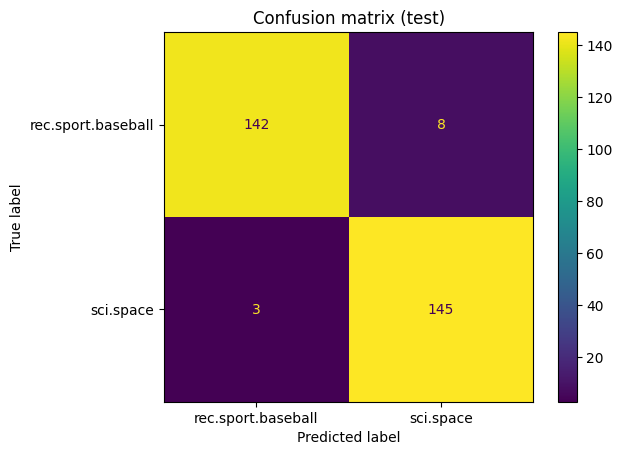

In [ ]:
# --- Confusion matrix (test) ---
disp = ConfusionMatrixDisplay.from_estimator(best_sgd_lr, X_test, y_test, display_labels=data.target_names)
plt.title("Confusion matrix (test)")
plt.grid(False)
plt.show()


## 3) Кривая лосса (как обучаем логрегрессию "итеративно")

Чтобы показать **кривую лосса**, будем обучать логрегрессию через **SGDClassifier(loss="log_loss")** по эпохам (`partial_fit`):
- это всё та же логистическая регрессия,
- но обучаемая градиентным спуском (SGD/mini-batch).

Мы зафиксируем **лучший C** (из GridSearch) и построим:
- train log-loss по эпохам
- val log-loss по эпохам


In [ ]:
# --- Подготовка: векторизуем отдельно (чтобы быстро считать loss) ---
print("best_alpha =", best_alpha)

vec = best_sgd_lr.named_steps["vec"]
Xtr = vec.transform(X_train)
Xva = vec.transform(X_val)

sgd = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=best_alpha,
    learning_rate="constant",
    eta0=0.02,
    random_state=7
)

classes = np.array([0, 1])


best_alpha = 1e-06


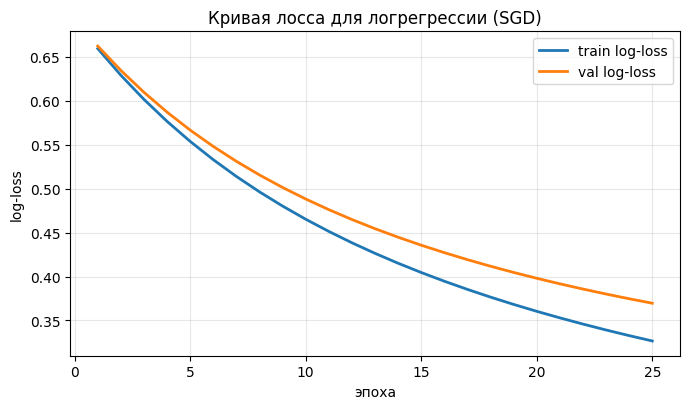

In [ ]:
# --- Обучение по эпохам + логирование log-loss ---
epochs = 25
train_losses = []
val_losses = []

for epoch in range(epochs):
    # partial_fit: одна эпоха SGD на всей обучающей матрице
    if epoch == 0:
        sgd.partial_fit(Xtr, y_train, classes=classes)
    else:
        sgd.partial_fit(Xtr, y_train)

    # вероятности нужны для log_loss
    p_tr = sgd.predict_proba(Xtr)
    p_va = sgd.predict_proba(Xva)

    train_losses.append(log_loss(y_train, p_tr))
    val_losses.append(log_loss(y_val, p_va))

plt.figure(figsize=(7, 4.2))
plt.plot(range(1, epochs+1), train_losses, linewidth=2, label="train log-loss")
plt.plot(range(1, epochs+1), val_losses, linewidth=2, label="val log-loss")
plt.xlabel("эпоха")
plt.ylabel("log-loss")
plt.title("Кривая лосса для логрегрессии (SGD)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# --- Accuracy и F1 для SGD-логрегрессии (на val/test) ---
Xte = vec.transform(X_test)

y_val_pred_sgd = sgd.predict(Xva)
y_test_pred_sgd = sgd.predict(Xte)

print("SGD VAL accuracy:", accuracy_score(y_val, y_val_pred_sgd))
print("SGD VAL macro-F1:", f1_score(y_val, y_val_pred_sgd, average="macro"))
print()
print("SGD TEST accuracy:", accuracy_score(y_test, y_test_pred_sgd))
print("SGD TEST macro-F1:", f1_score(y_test, y_test_pred_sgd, average="macro"))


SGD VAL accuracy: 0.9225589225589226
SGD VAL macro-F1: 0.9225589225589226

SGD TEST accuracy: 0.9630872483221476
SGD TEST macro-F1: 0.9630835069542204


## 4) Тепловая карта вероятностей (визуализация)

Тексты живут в огромном TF‑IDF пространстве, поэтому для рисунка делаем:

1) `TruncatedSVD(n_components=2)` — проекция в 2D (LSA).  
2) Обучаем логрегрессию уже в 2D и рисуем:
   - decision boundary
   - heatmap вероятностей \(p(+\mid \mathbf{x})\)

Важно: это **визуализация**, а не “настоящая” модель из пункта 2.


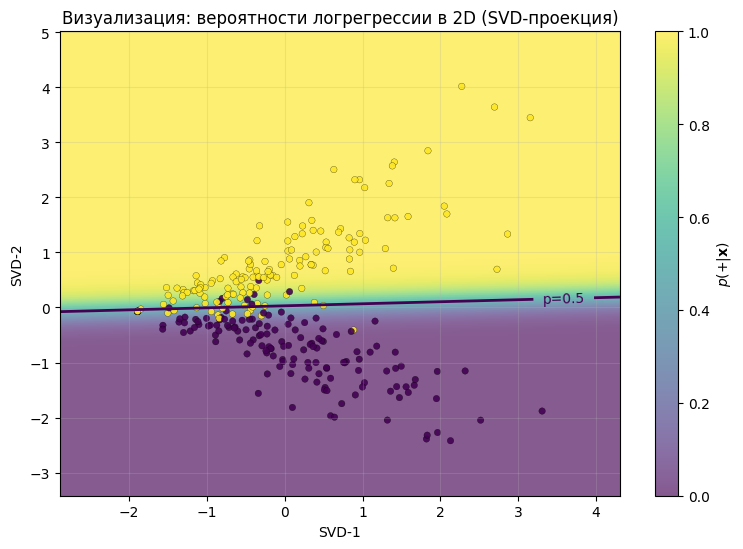

In [ ]:
# --- 2D проекция TF-IDF -> SVD ---
svd = TruncatedSVD(n_components=2, random_state=7)
Xtr_2d = svd.fit_transform(Xtr)
Xva_2d = svd.transform(Xva)

# Небольшая стандартизация помогает для красивых границ
sc = StandardScaler()
Xtr_2d = sc.fit_transform(Xtr_2d)
Xva_2d = sc.transform(Xva_2d)

lr_2d = SGDClassifier(loss="log_loss", penalty="l2", alpha=best_alpha,
                     learning_rate="constant", eta0=0.02, max_iter=2000,
                     tol=1e-6, random_state=7)
lr_2d.fit(Xtr_2d, y_train)

# --- сетка для heatmap ---
x_min, x_max = Xva_2d[:, 0].min() - 1.0, Xva_2d[:, 0].max() + 1.0
y_min, y_max = Xva_2d[:, 1].min() - 1.0, Xva_2d[:, 1].max() + 1.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = np.c_[xx.ravel(), yy.ravel()]

proba = lr_2d.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(7.8, 5.6))
im = plt.imshow(
    proba, origin="lower",
    extent=(x_min, x_max, y_min, y_max),
    aspect="auto", alpha=0.65,
    vmin=0.0, vmax=1.0
)
plt.colorbar(im, label=r"$p(+|\mathbf{x})$")

# граница p=0.5
cs = plt.contour(xx, yy, proba, levels=[0.5], linewidths=2)
plt.clabel(cs, fmt={0.5: "p=0.5"})

# точки валидации
plt.scatter(Xva_2d[:, 0], Xva_2d[:, 1], c=y_val, s=22, edgecolors="black", linewidths=0.2, alpha=0.9)

plt.title("Визуализация: вероятности логрегрессии в 2D (SVD-проекция)")
plt.xlabel("SVD-1")
plt.ylabel("SVD-2")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## 5) L1-регуляризация: разреженные веса и важные признаки

L1 часто зануляет многие веса и работает как **feature selection**.

Мы обучим логрегрессию с L1 и посмотрим:
- какие слова получили самый большой положительный вес (поддерживают класс `rec.sport.baseball` или `sci.space` — зависит от кодировки меток)
- какие — самый большой отрицательный.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

alphas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

models_by_alpha = {}   # alpha -> обученная модель (Pipeline)
results_l1 = []        # (alpha, acc, f1, sparsity)

for a in alphas:
    model = Pipeline([
        ("vec", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            min_df=3,
            ngram_range=(1, 1),
        )),
        ("clf", SGDClassifier(
            loss="log_loss",
            penalty="l1",
            alpha=a,
            learning_rate="constant",
            eta0=0.02,
            max_iter=50,
            tol=1e-6,
            random_state=7
        ))
    ])

    model.fit(X_train, y_train)
    models_by_alpha[a] = model  # сохраняем модель

    y_val_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    f1  = f1_score(y_val, y_val_pred, average="macro")

    coef = model.named_steps["clf"].coef_.ravel()
    sparsity = (coef == 0).mean()

    results_l1.append((a, acc, f1, sparsity))

print("alpha       acc_val   f1_val   sparsity")
for a, acc, f1, sp in results_l1:
    print(f"{a:<10g} {acc:>7.3f} {f1:>8.3f} {sp:>10.3f}")

# лучший по F1
best_alpha = max(results_l1, key=lambda x: x[2])[0]
best_l1 = models_by_alpha[best_alpha]
print("\nЛучший alpha по F1:", best_alpha)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


alpha       acc_val   f1_val   sparsity
1e-06        0.926    0.926      0.004
1e-05        0.926    0.926      0.059
0.0001       0.923    0.923      0.532
0.001        0.862    0.861      0.980
0.01         0.502    0.334      1.000

Лучший alpha по F1: 1e-06


In [ ]:
best_balanced_alpha_l1, best_balanced_acc_l1, best_balanced_f1_l1, best_balanced_sp_l1 = results_l1[2]
best_balanced_l1 = models_by_alpha[best_balanced_alpha_l1]
print("\nСбалансированный alpha по F1:", best_balanced_alpha_l1, "| f1_val:", best_balanced_f1_l1, "| sparsity:", best_balanced_sp_l1)


Сбалансированный alpha по F1: 0.0001 | f1_val: 0.9225589225589226 | sparsity: 0.5323601829053817


In [ ]:
y_test_pred_l1 = best_balanced_l1.predict(X_test)
print("TEST accuracy (L1):", accuracy_score(y_test, y_test_pred_l1))
print("TEST macro-F1 (L1):", f1_score(y_test, y_test_pred_l1, average="macro"))


TEST accuracy (L1): 0.9563758389261745
TEST macro-F1 (L1): 0.9563714173095332


In [ ]:
# --- Важные признаки (топ-слова) ---
vec_l1 = best_balanced_l1.named_steps["vec"]
clf_l1 = best_balanced_l1.named_steps["clf"]

feature_names = np.array(vec_l1.get_feature_names_out())
coef = clf_l1.coef_.ravel()  # shape (n_features,)

# Сколько весов стало ровно 0?
zero_frac = (coef == 0).mean()
print(f"Доля нулевых весов (sparsity): {zero_frac:.3f}")

top_k = 20

pos_idx = np.argsort(coef)[-top_k:][::-1]
neg_idx = np.argsort(coef)[:top_k]

print("\nТоп признаков, которые увеличивают p(y=1):")
for w, c in zip(feature_names[pos_idx], coef[pos_idx]):
    print(f"{w:>20s}  {c: .3f}")

print("\nТоп признаков, которые увеличивают p(y=0):")
for w, c in zip(feature_names[neg_idx], coef[neg_idx]):
    print(f"{w:>20s}  {c: .3f}")


Доля нулевых весов (sparsity): 0.532

Топ признаков, которые увеличивают p(y=1):
               space   6.058
                nasa   2.597
               orbit   2.478
              launch   2.314
             shuttle   2.310
               earth   2.301
                moon   2.201
               solar   1.637
             program   1.587
                 sky   1.587
          spacecraft   1.482
                cost   1.480
             mission   1.472
           satellite   1.308
            software   1.297
             project   1.247
                 hst   1.247
                 sci   1.219
                  dc   1.177
              people   1.162

Топ признаков, которые увеличивают p(y=0):
                game  -3.965
            baseball  -3.423
               games  -3.096
                year  -3.080
                team  -2.700
                 hit  -2.584
             players  -2.405
              league  -2.001
              season  -1.999
                ball  -1.866
     

## 6) Что можно улучшить (в качестве дополнительной работы)

1) **Сравнить с SVM**  
   - `LinearSVC(C=...)` или `SGDClassifier(loss="hinge")`  
   - сравнить accuracy и macro-F1.

2) **Попробовать другие векторизации**  
   - TF‑IDF с bigrams: `ngram_range=(1,2)`  
   - char n‑grams (часто помогает даже на английском, а на русском особенно).

3) **Подобрать параметры векторайзера**  
   - `min_df`, `max_df`, `stop_words`.


# Домашнее задание (RU)

Возьмите датасет на русском. Это может быть датасет из прошлой домашки (новости), или новый, например  
**`data-silence/rus_news_classifier`** (HuggingFace Datasets)

Сделайте аналогичный ноутбук:

1) Один базовый векторайзер (TF‑IDF), логрегрессия (подбор $\alpha$), метрики accuracy и macro‑F1. Подбор гиперпараметров (eta, tol, max_iter). Сделайте необходимую предобработку для "мешка слов" на русском
2) Линейный SVM (подбор C), сравнить метрики.  
3) Добавить L1-регуляризацию и вывести топ‑признаки (слова/n‑граммы) для 2–3 классов.  
4) (Бонус) Попробовать **char n‑grams TF‑IDF** и сравнить с word TF‑IDF.

Сдача: таблица результатов + 3-5 предложений выводов.
